# Eda


## Setup

Load the cleaned dataset produced in the previous notebook.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Full_Set = pd.read_csv("../Dataset/output1.csv")
Full_Set = Full_Set.drop(columns=["Unnamed: 0", "id"], errors="ignore")
Full_Set.head()

<h1>Analysis on the dataset's features</h1>


<h3>We will recall the definition of numerical and categorical variables then classify those features as one of the two and then perform futher analysis and testing. 

- Numerical features: Numerical features are variables that have a numeric value. They can be either discrete or continuous. Discrete numerical features are those that have a finite number of possible values (e.g. number of bedrooms in a house), while continuous numerical features can take any value within a range (e.g. height or weight). Examples of numerical features in our dataset include Flight_Distance, Age, Inflight_wifi_service, Departure_Delay_in_Minutes, and Arrival_Delay_in_Minutes.

- Categorical features: Categorical features are variables that have a limited number of values. They can be further classified into nominal and ordinal variables. Nominal variables are those that do not have an inherent order or rank (e.g. gender or type of travel), while ordinal variables have a specific order or rank (e.g. rating on a scale of 1-5). Examples of categorical features in our dataset include Gender, Customer_Type, Type_of_Travel, Class, and satisfaction, as well as the various service ratings such as Inflight_wifi_service and Cleanliness.</h3>

#### Now we won't do the grouping yet, we will use the pre-grouped data 'Full_Set' in our Correlation Analysis and see what happens.

# Correlation Analysis

<h4>To perform correlation analysis, we can use the corr() function to calculate the correlation matrix between all pairs of columns in the data set. Then we can use a data visualization tools such as heatmaps and scatterplots to better understand the relationships between the variables.</h4>

In [14]:
# calculate the correlation matrix
corr_matrix = Full_Set.corr()

C:\Users\User\AppData\Local\Temp\ipykernel_31280\211183477.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = Full_Set.corr()


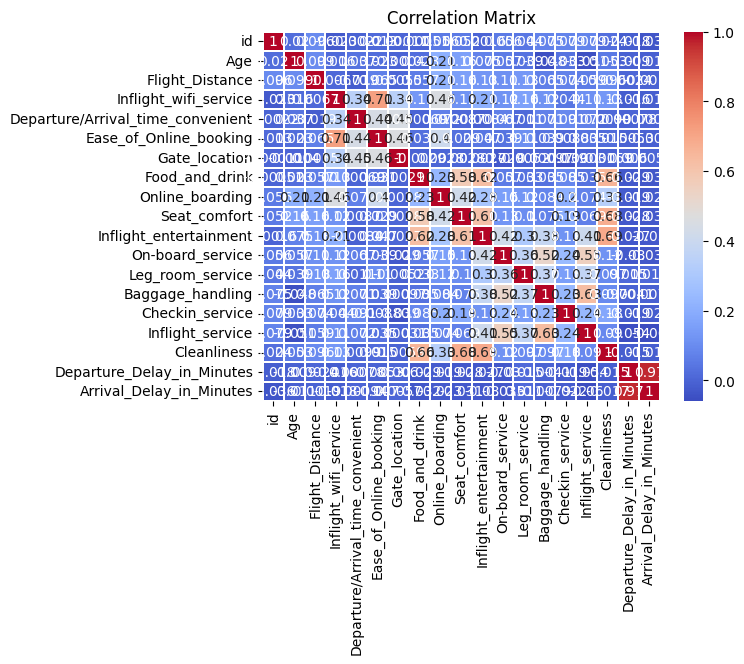

In [15]:
# plot a heatmap of the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.25)
plt.title('Correlation Matrix')
plt.show()

<p>As we can see that it is very difficult to read what's going on in the above heat map. Therefore, it is important to note that we need to identify the data type of our features clearly before diving too deep into the further analysis.</p>

<h3>Here is the grouping of our features into numerical and categorical type: </h3>

Categorical Features:
<ul>
  <li>Gender</li>
  <li>Customer_Type</li>
  <li>Type_of_Travel</li>
  <li>Class</li>
  <li>satisfaction</li>
</ul>



Numerical Features:
<ul>
  <li>Age</li>
  <li>Flight_Distance</li>
  <li>Inflight_wifi_service</li>
  <li>Departure/Arrival_time_convenient</li>
  <li>Ease_of_Online_booking</li>
  <li>Gate_location</li>
  <li>Food_and_drink</li>
  <li>Online_boarding</li>
  <li>Inflight_entertainment</li>
  <li>On-board_service</li>
  <li>Leg_room_service</li>
  <li>Baggage_handling</li>
  <li>Checkin_service</li>
  <li>Inflight_service</li>
  <li>Cleanliness</li>
  <li>Departure_Delay_in_Minutes</li>
  <li>Arrival_Delay_in_Minutes</li>
</ul>


In [24]:
numerical_cols = ['id', 'Age', 'Flight_Distance','Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes']

In [25]:
categorical_cols = Full_Set.select_dtypes(include='category')

In [26]:
Full_Set[categorical_cols.columns.tolist()] = Full_Set[categorical_cols.columns.tolist()].astype('category')

##### Use the above columns for testing numerical and categorical features

In [27]:
Full_Set.dtypes

id                                     int64
Gender                                object
Customer_Type                         object
Age                                    int64
Type_of_Travel                        object
Class                                 object
Flight_Distance                        int64
Inflight_wifi_service                  int64
Departure/Arrival_time_convenient      int64
Ease_of_Online_booking                 int64
Gate_location                          int64
Food_and_drink                         int64
Online_boarding                        int64
Seat_comfort                           int64
Inflight_entertainment                 int64
On-board_service                       int64
Leg_room_service                       int64
Baggage_handling                       int64
Checkin_service                        int64
Inflight_service                       int64
Cleanliness                            int64
Departure_Delay_in_Minutes             int64
Arrival_De

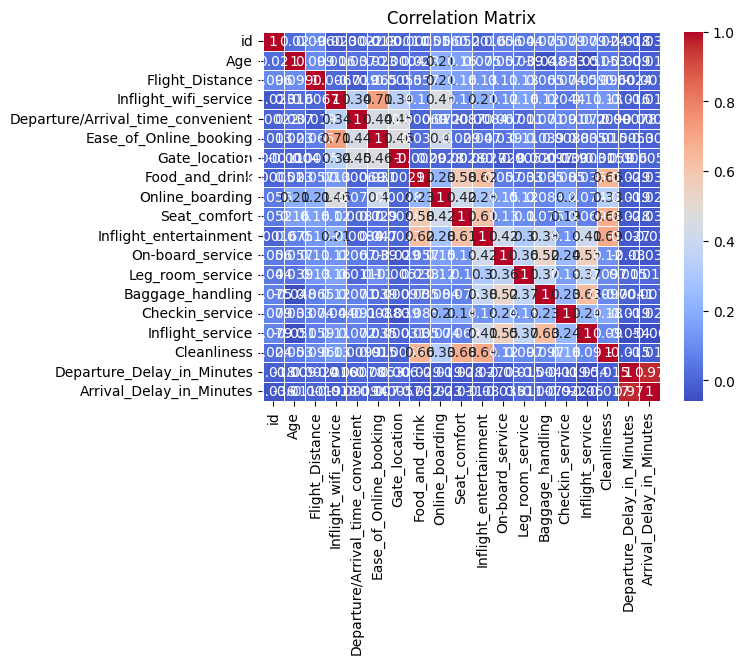

In [28]:
corr_matrix = Full_Set.corr(numeric_only=True)
# plot a heatmap of the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

### Well it certainly got better but we need to make some more adjustments to the parameters of the heatmap plots.

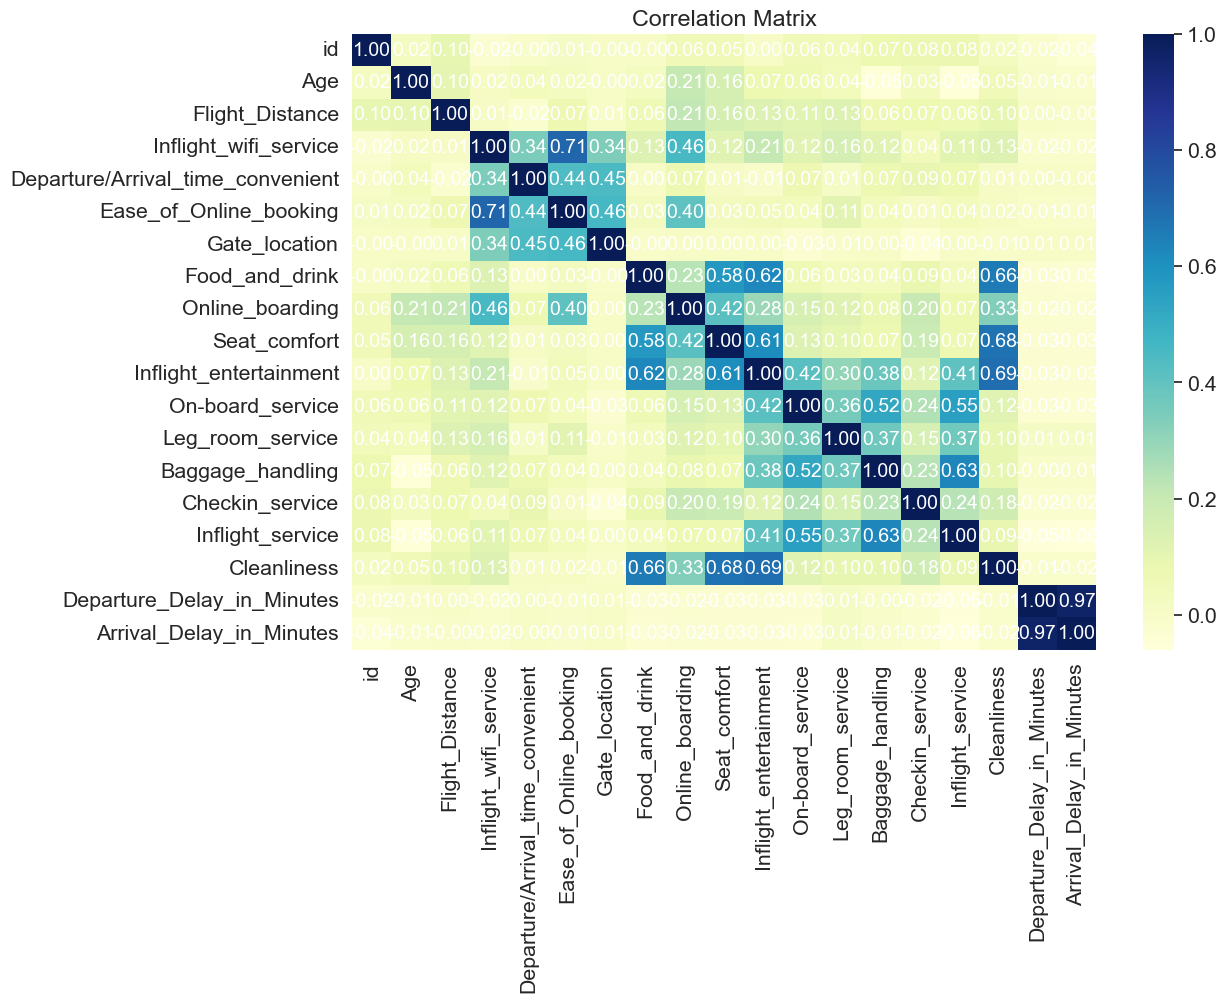

In [29]:
plt.figure(figsize=(12,8))
sns.set(font_scale=1.4)
sns.set_style("white")
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt='.2f', annot_kws={"size": 14, "color": 'white'})
plt.title('Correlation Matrix')
plt.show()

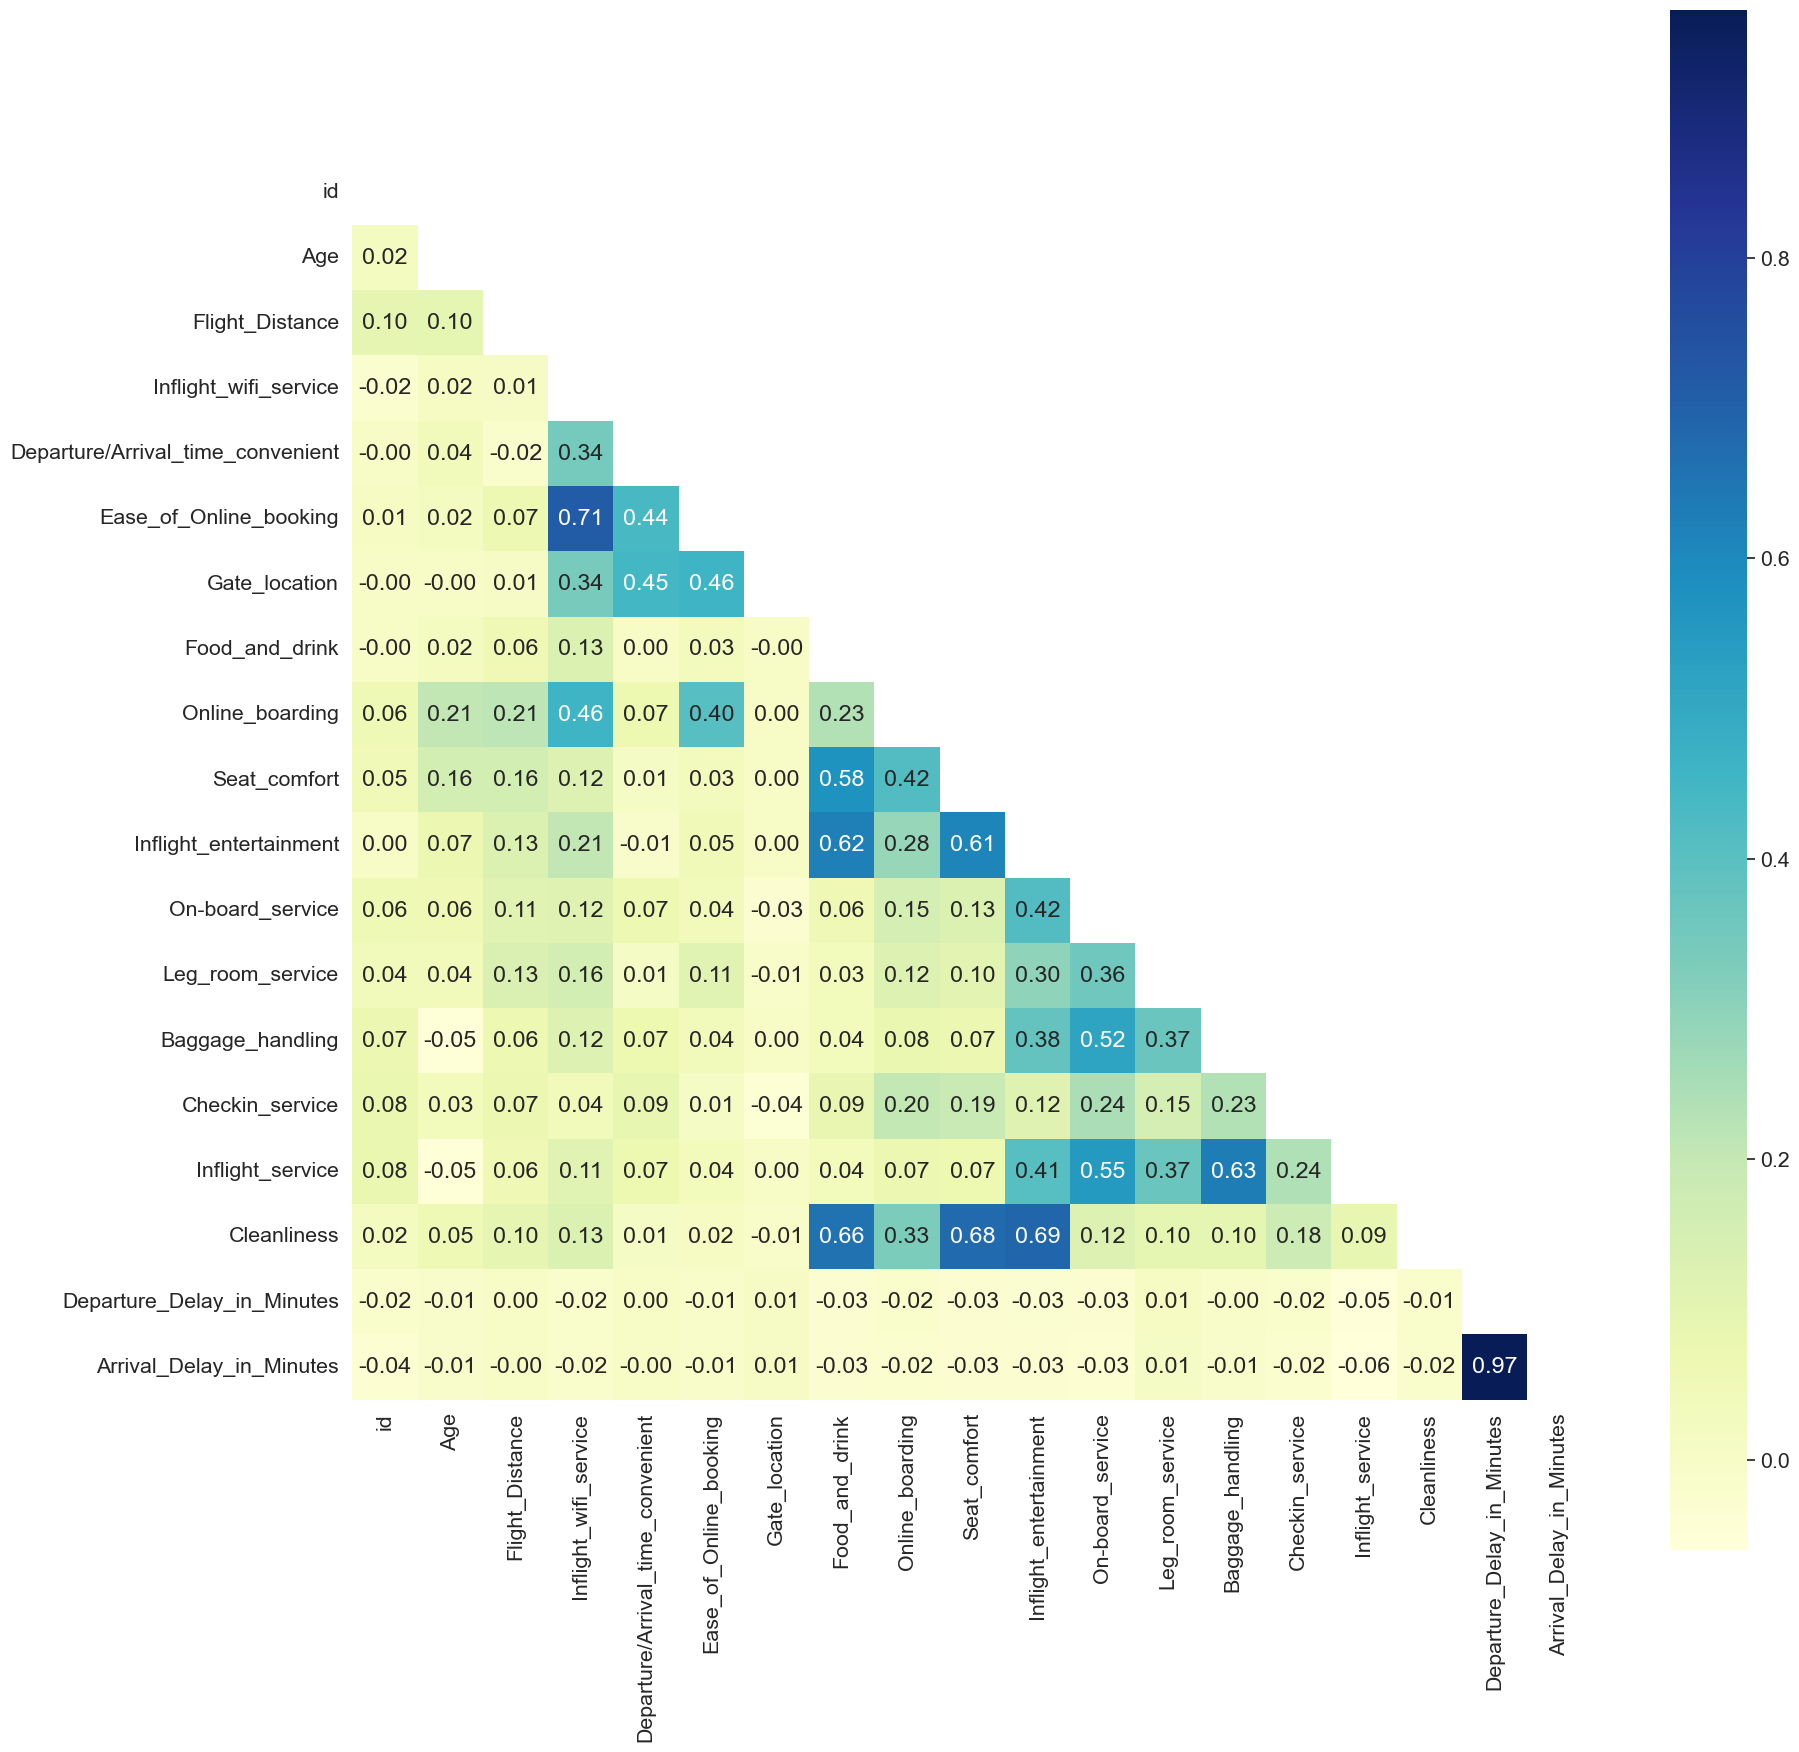

In [30]:
# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap with masked upper triangle
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, cmap="YlGnBu", annot=True, fmt=".2f", mask=mask, square=True)
plt.show()

Inflight_wifi_service is very correlated with Ease_of_Online_booking. The ratings for Cleanliness are also correlated to the ratings of Food_and_drink, Seat_Comfort, and Inflight_entertainment. But the two features that are highly correlated are the Departure_Delay_in_Minutes and the Arrival_Delay_in_Minutes, which is very obvious, logically speaking.

### Let's filter down to 4 numerical features instead....

In [9]:
cols = ['Age', 'Flight_Distance', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes']
filtered_numerical_data = Full_Set[cols]
filtered_numerical_data

,Age,Flight_Distance,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes
0,13,460,25,18.0
1,25,235,1,6.0
2,26,1142,0,0.0
3,25,562,11,9.0
4,61,214,0,0.0
...,...,...,...,...
129875,34,526,0,0.0
129876,23,646,0,0.0
129877,17,828,0,0.0
129878,14,1127,0,0.0


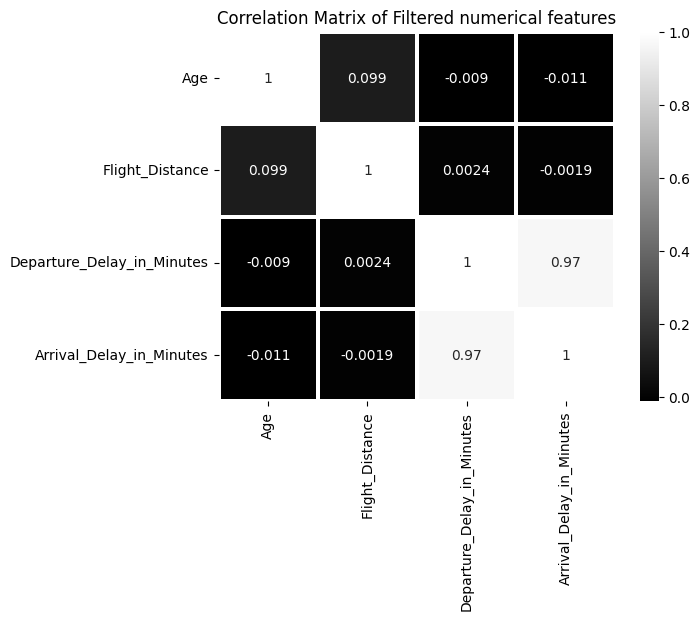

In [10]:
corr_matrix_1 = filtered_numerical_data.corr()

# plot the heatmap
sns.heatmap(corr_matrix_1, annot=True, cmap='gray', linewidths=1.6)
plt.title('Correlation Matrix of Filtered numerical features')
plt.show()

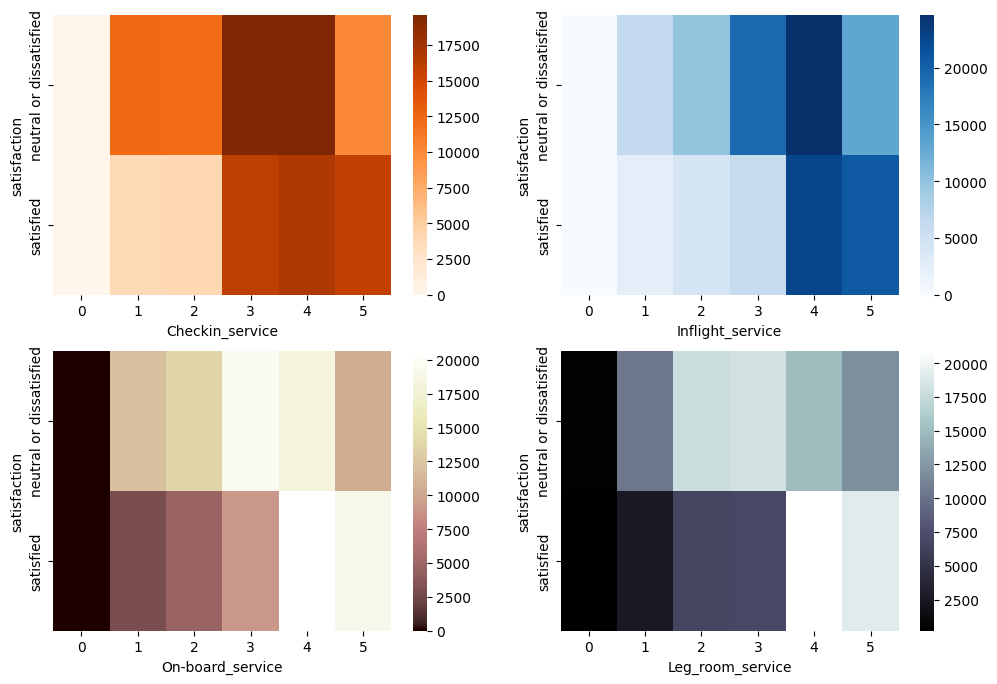

In [16]:
fig, axarr = plt.subplots(2, 2, figsize=(12, 8))

table1 = pd.crosstab(Full_Set['satisfaction'], Full_Set['Checkin_service'])
sns.heatmap(table1, cmap='Oranges', ax = axarr[0][0])
table2 = pd.crosstab(Full_Set['satisfaction'], Full_Set['Inflight_service'])
sns.heatmap(table2, cmap='Blues', ax = axarr[0][1])
table3 = pd.crosstab(Full_Set['satisfaction'], Full_Set['On-board_service'])
sns.heatmap(table3, cmap='pink', ax = axarr[1][0])
table4 = pd.crosstab(Full_Set['satisfaction'], Full_Set['Leg_room_service'])
sns.heatmap(table4, cmap='bone', ax = axarr[1][1])
plt.show()

*Checkin Service, Inflight Service, On-board Service, Leg-room Service*:  
For checkin service, 0-2 rating givers are predominantly dissatisfied. For other three services, only 4 and 5 rating givers belong to satisfied passengers category.

## Pairplot 

In [31]:
def pairplot(data):
    sns.pairplot(data, hue = 'satisfaction', palette="flare")
    plt.show()
    
pairplot(Full_Set)

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x000001805686CC10> (for post_execute):


KeyboardInterrupt: 

# Taking too long...........need more optimization

## Explaination: 

As we can see that the points lined up more or less along a straight line going from the lower left corner to the upper right. Thus, in some approximation the dependence of the arrival time delay on the departure time delay is linear.

The results obtained are quite logical and can be explained as follows. If the flight of the airline's customers was delayed by a certain amount of time at departure, then the flight will be delayed by about the same amount of time at landing (provided that the aircraft does not accelerate in flight to make up for lost time).

## Boxplot

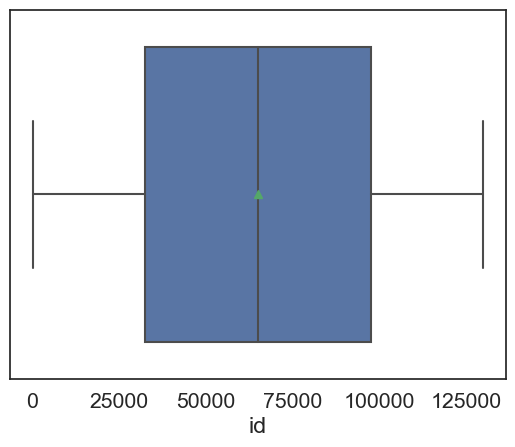

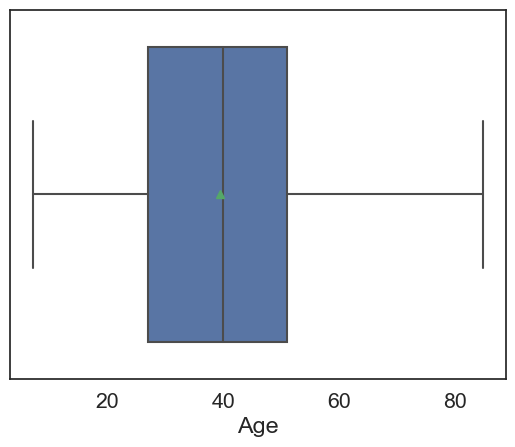

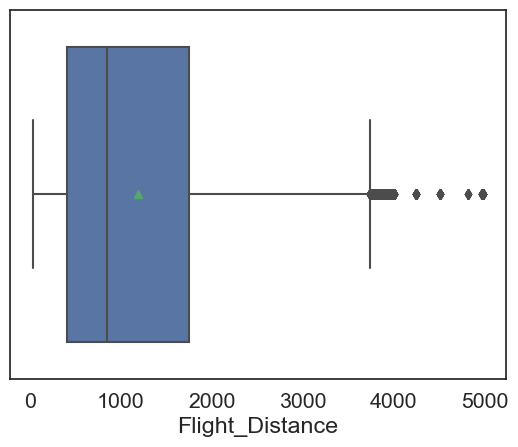

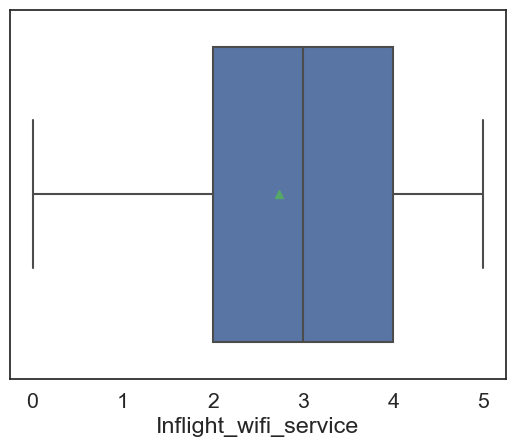

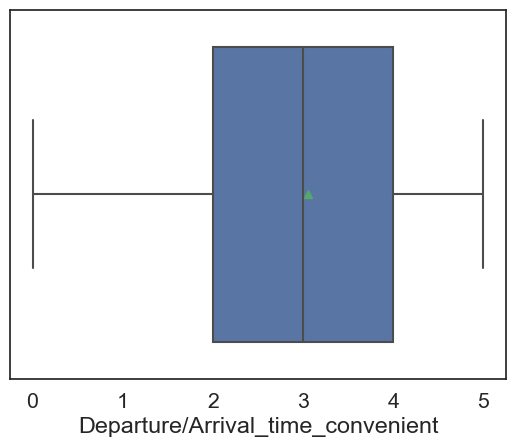

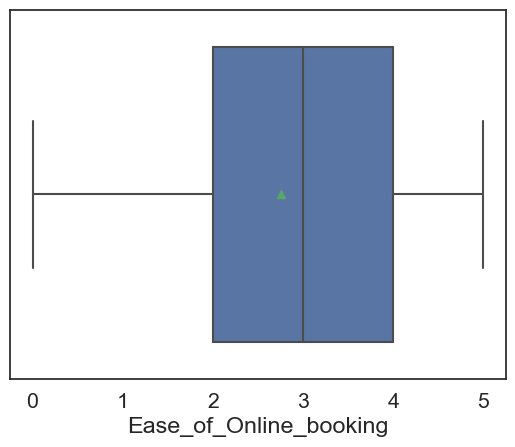

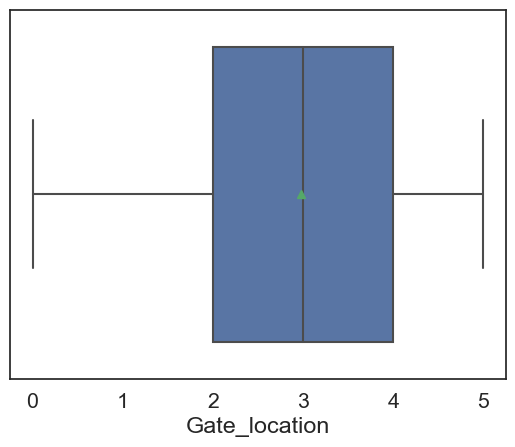

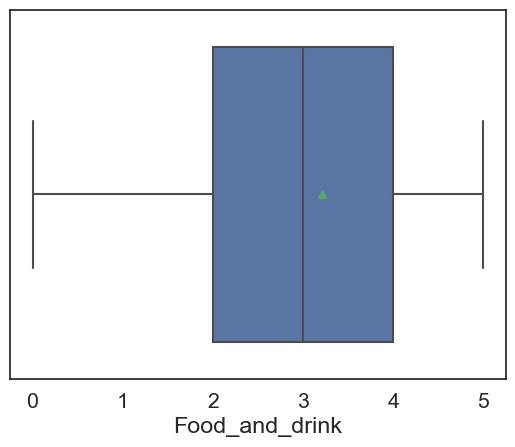

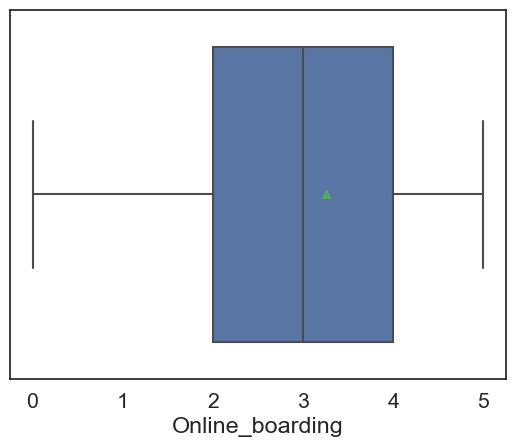

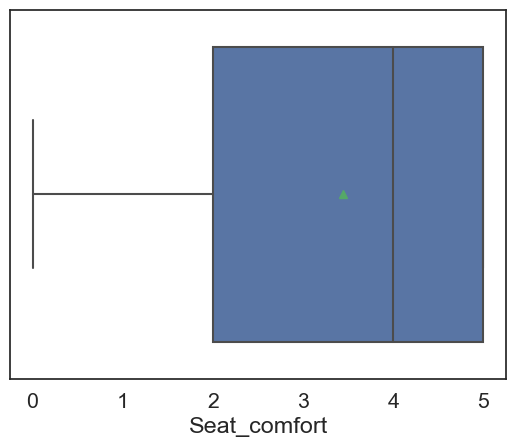

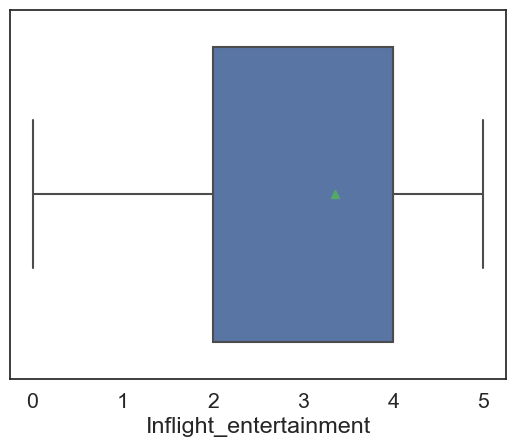

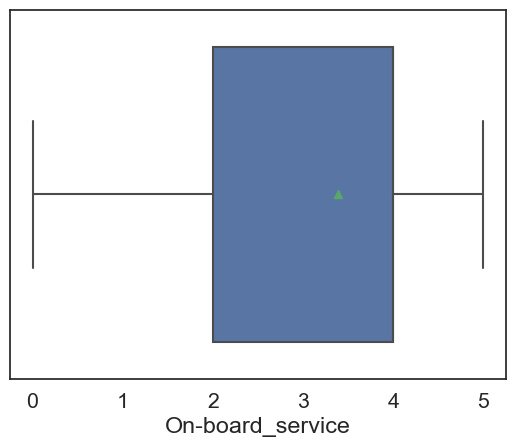

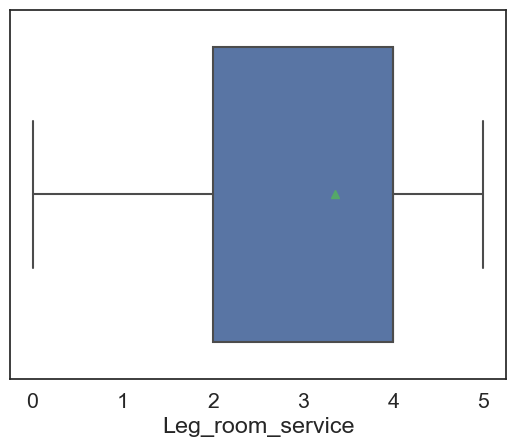

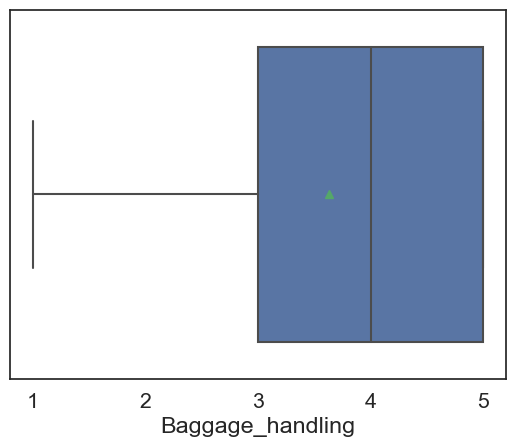

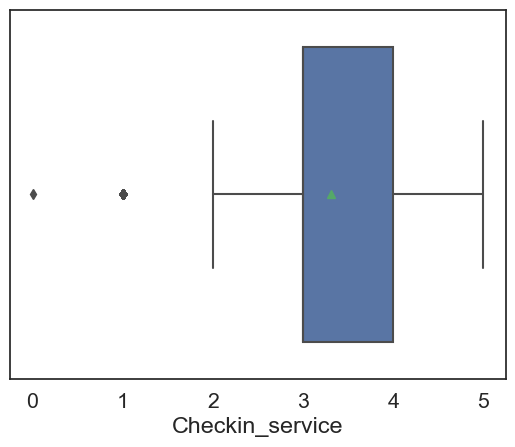

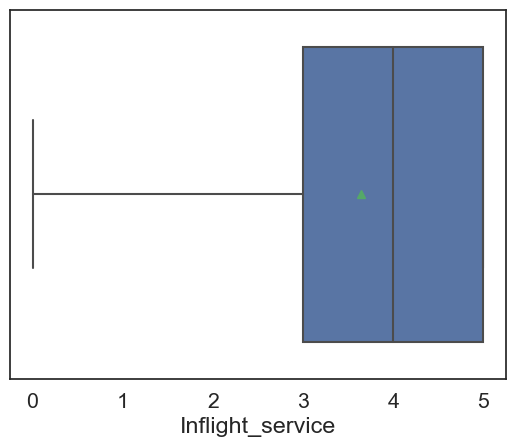

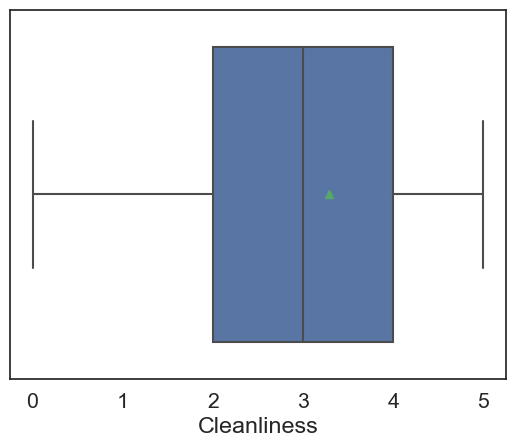

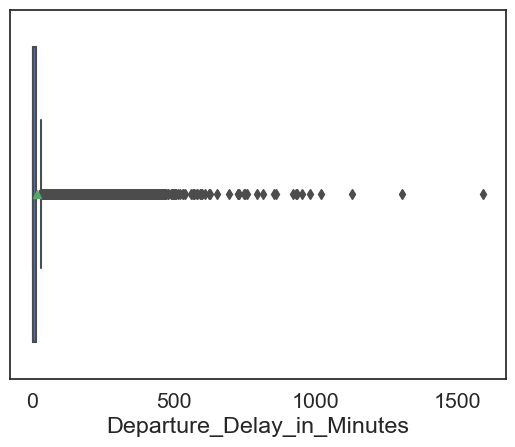

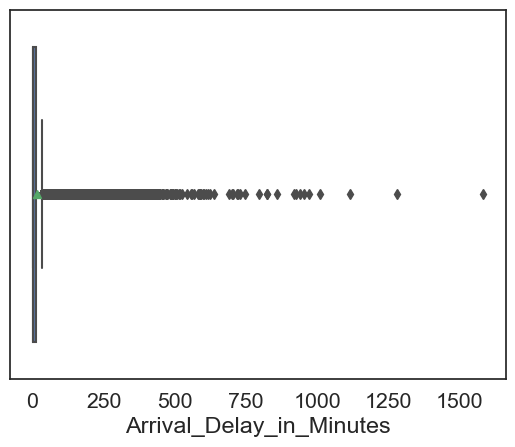

In [32]:
def plot_boxplot(data, feature):
        sns.boxplot(x = data[feature], showmeans = True, data = data)
        plt.show()

numerical_features = Full_Set.select_dtypes(include=['int64', 'float64'])

#features = ['Flight_Distance', 'Departure_Delay_in_Minutes'  , 'Arrival_Delay_in_Minutes'] # numerical features
for feature in numerical_features:
    plot_boxplot(Full_Set, feature)

## Explaination: 

As we can see from those boxplots above, there are many outliers occured in some of our numerical features 

# Pie Chart

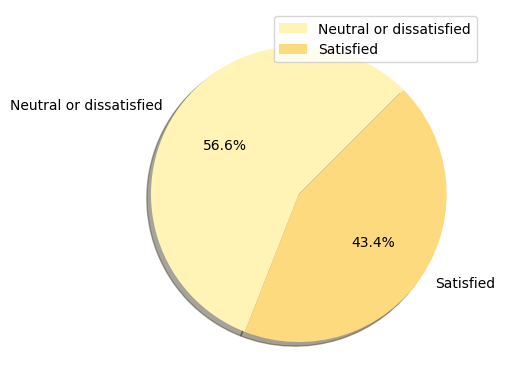

In [5]:
plt.pie(Full_Set.satisfaction.value_counts(), labels = ["Neutral or dissatisfied", "Satisfied"], \
        colors = sns.color_palette("YlOrBr"), autopct = '%1.1f%%', shadow = True,  startangle = 45)
plt.legend(loc = 'best')
plt.show()

### Explaination:
As we can see from the pie chart above, it shows that the target variable of our data is **more or less balanced.**

# The Ratio of categorical feature(univariate analysis) or Ordinal Analysis

In [20]:
Full_Set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 129880 non-null  int64  
 1   Gender                             129880 non-null  object 
 2   Customer_Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type_of_Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight_Distance                    129880 non-null  int64  
 7   Inflight_wifi_service              129880 non-null  int64  
 8   Departure/Arrival_time_convenient  129880 non-null  int64  
 9   Ease_of_Online_booking             129880 non-null  int64  
 10  Gate_location                      129880 non-null  int64  
 11  Food_and_drink                     1298

In [23]:
def generate_pie_charts(dataframe):
    columns = dataframe.columns

    exclude_columns = ['id','Unnamed:_0','Age', 'Flight_Distance', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes']

    for column in columns:
        if column not in exclude_columns:
            plt.figure(figsize=(8, 6))
            counts = dataframe[column].value_counts()
            labels = counts.index
            frequencies = counts.values
            colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']

            plt.pie(frequencies, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)

            plt.axis('equal')
            plt.title(f"{column} - Frequency")
            plt.legend(title="Categories", loc='upper right', bbox_to_anchor=(1, 0, 0.5, 1))

            plt.show()



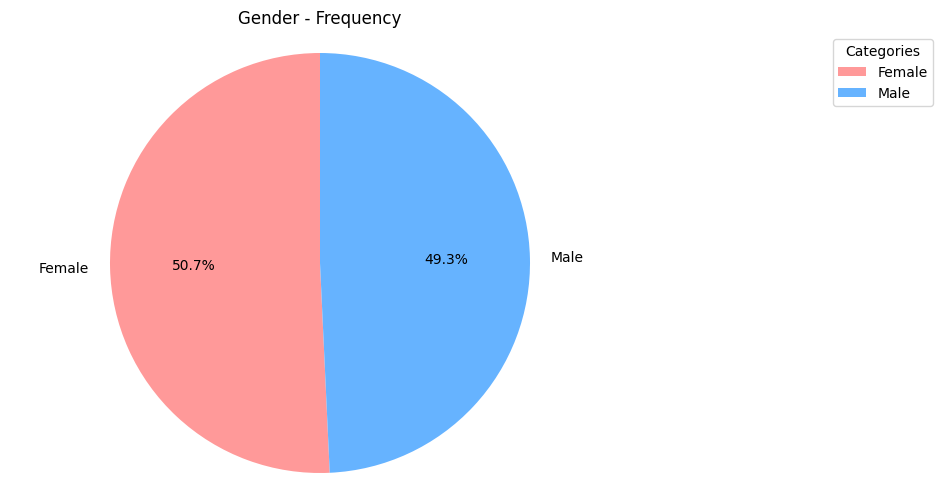

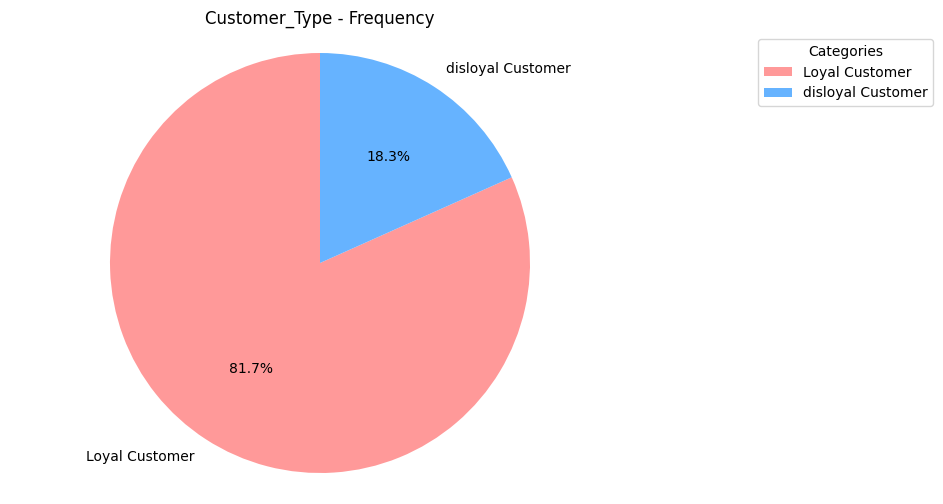

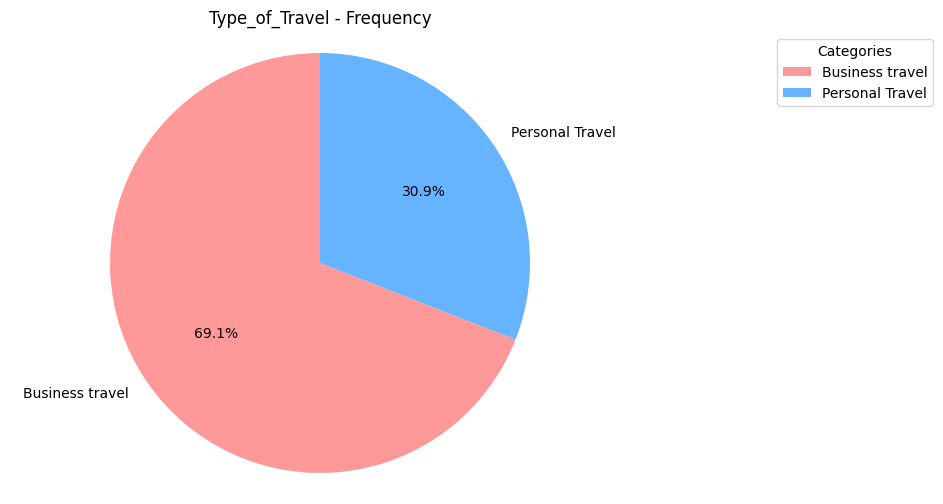

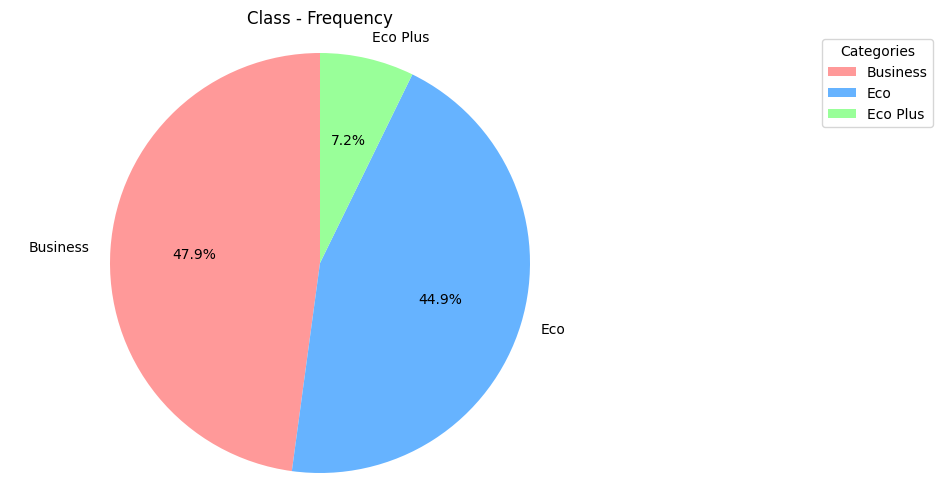

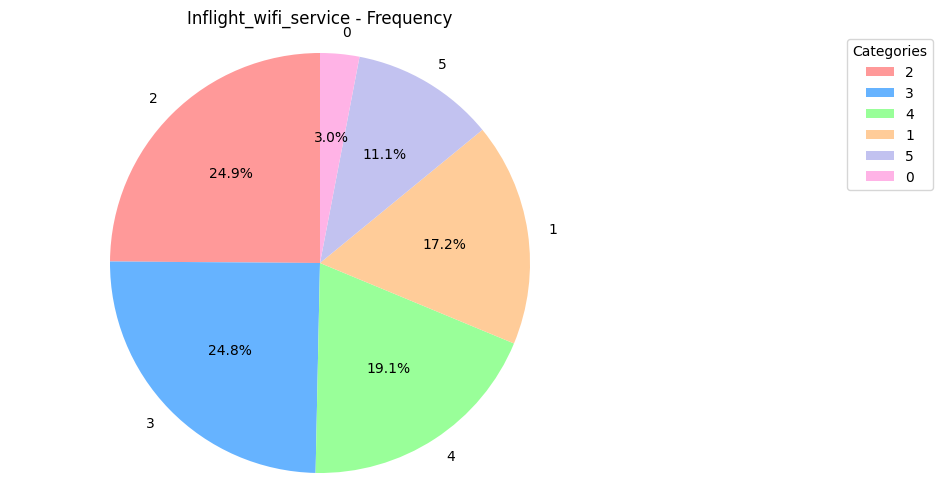

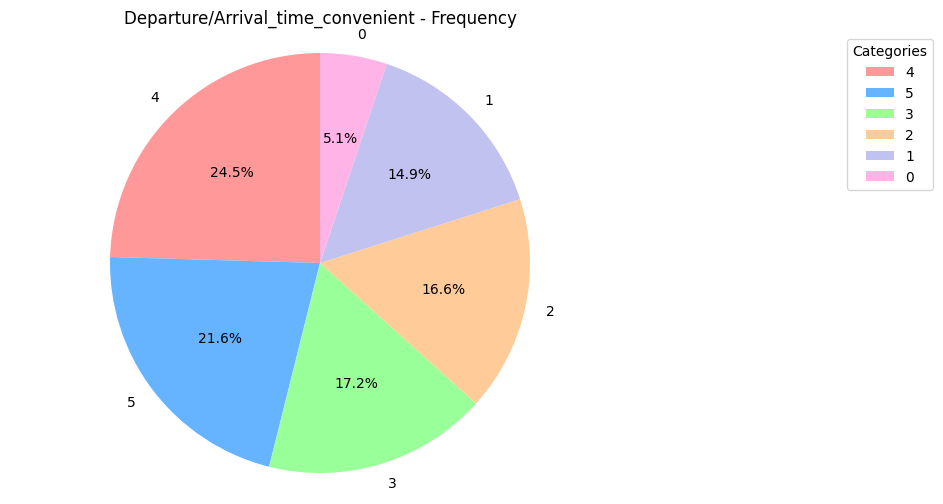

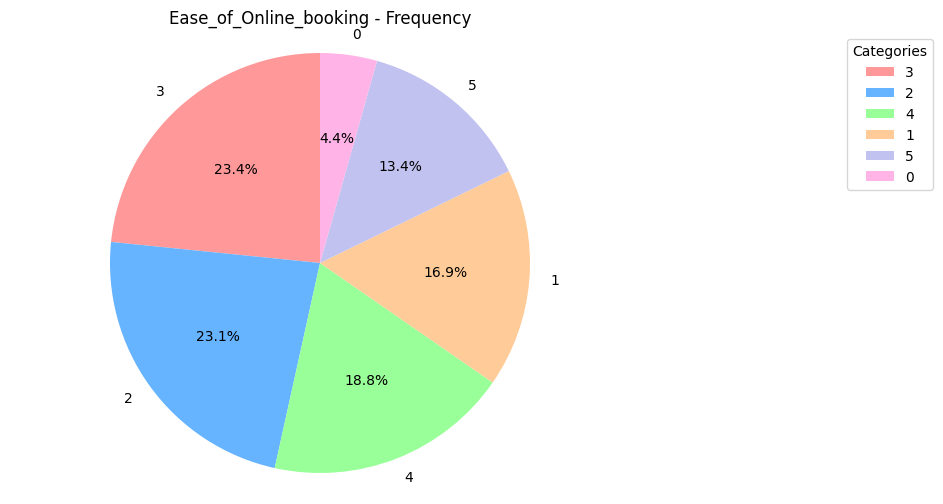

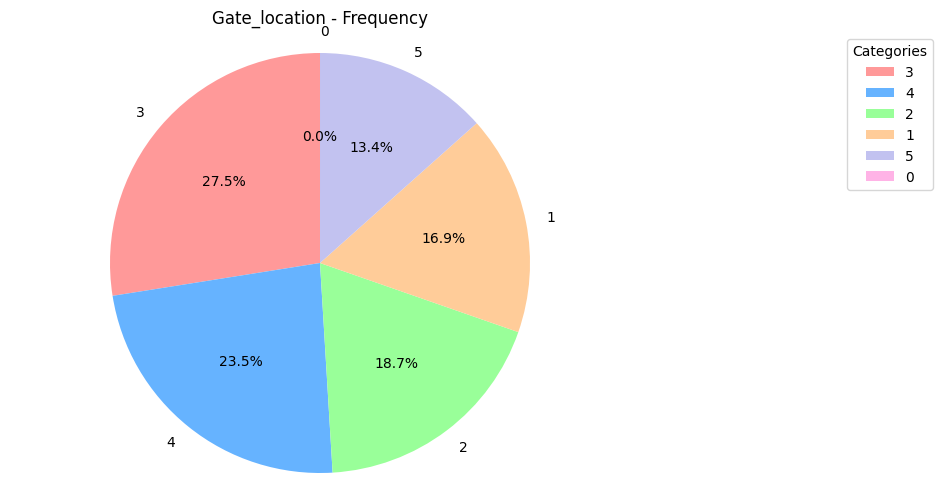

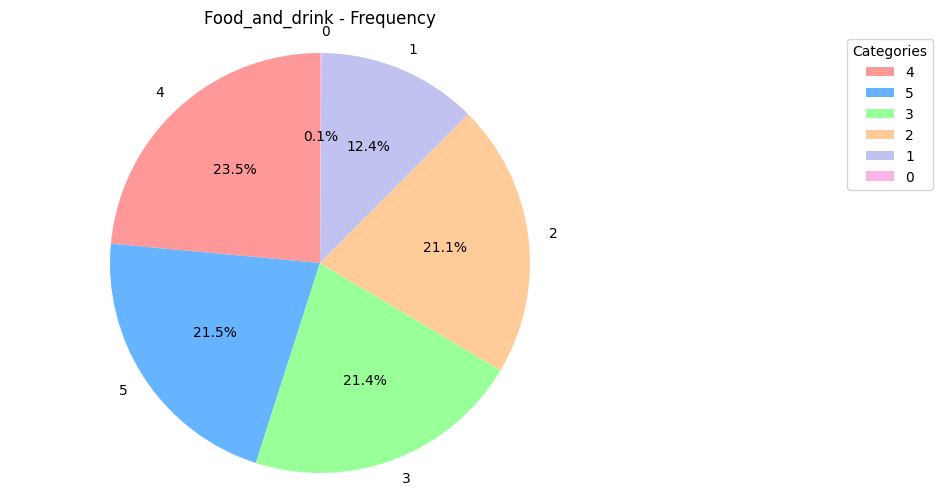

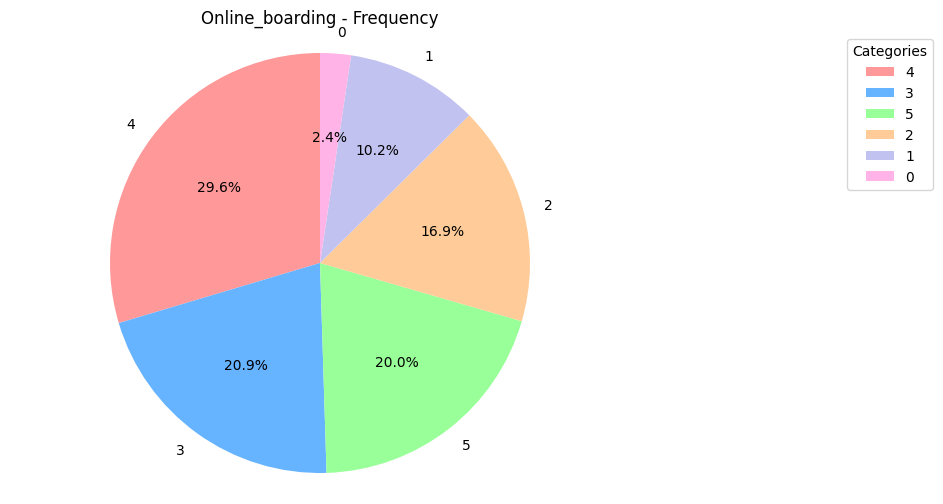

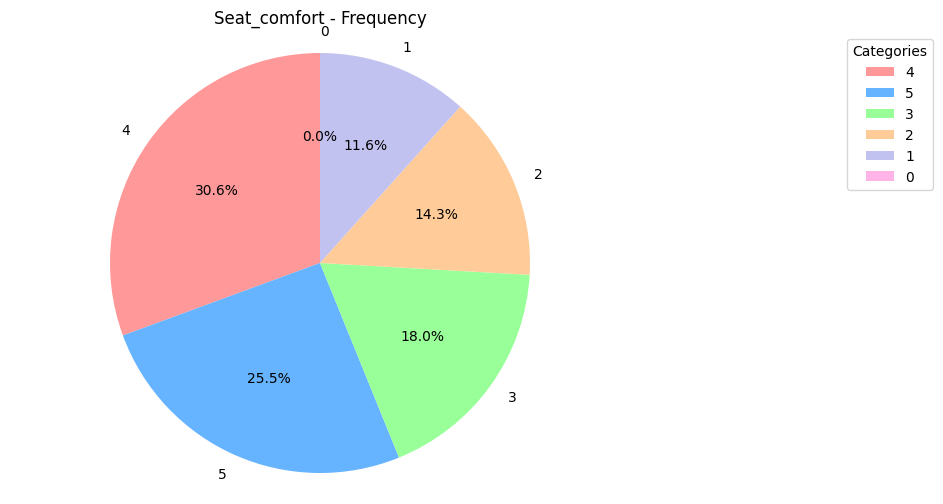

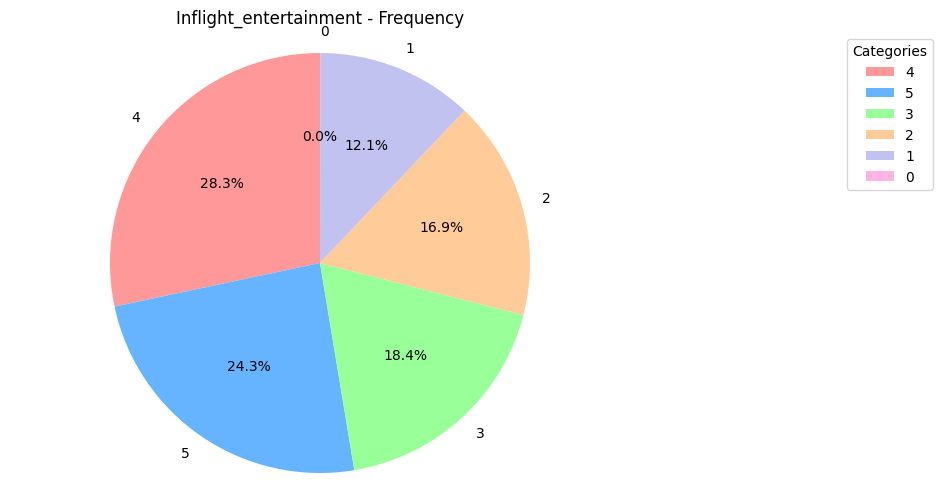

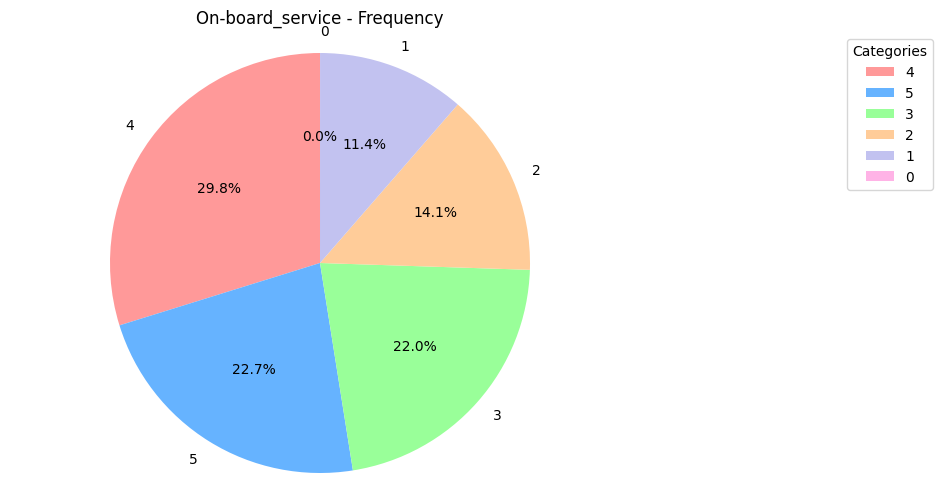

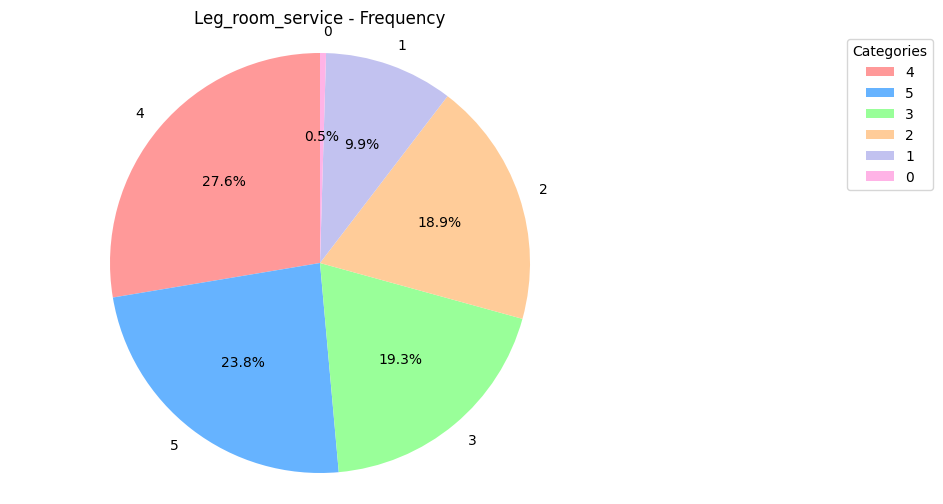

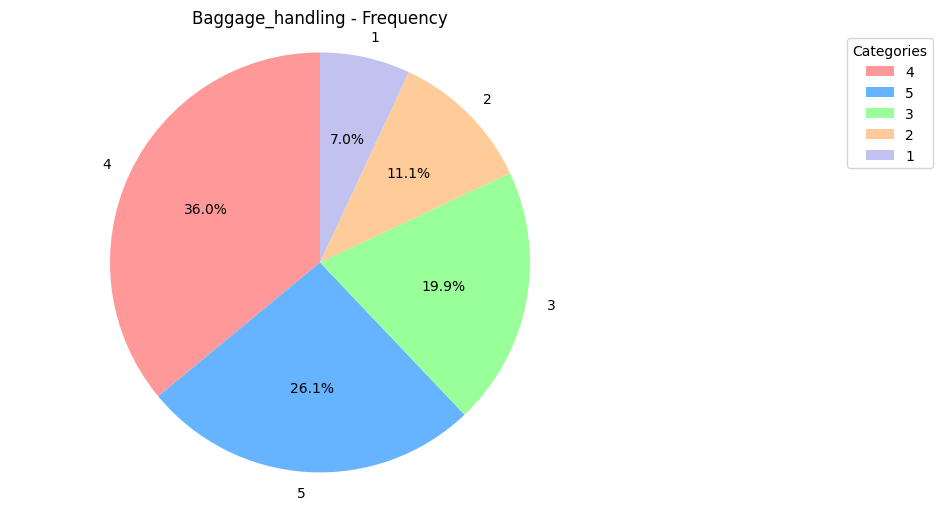

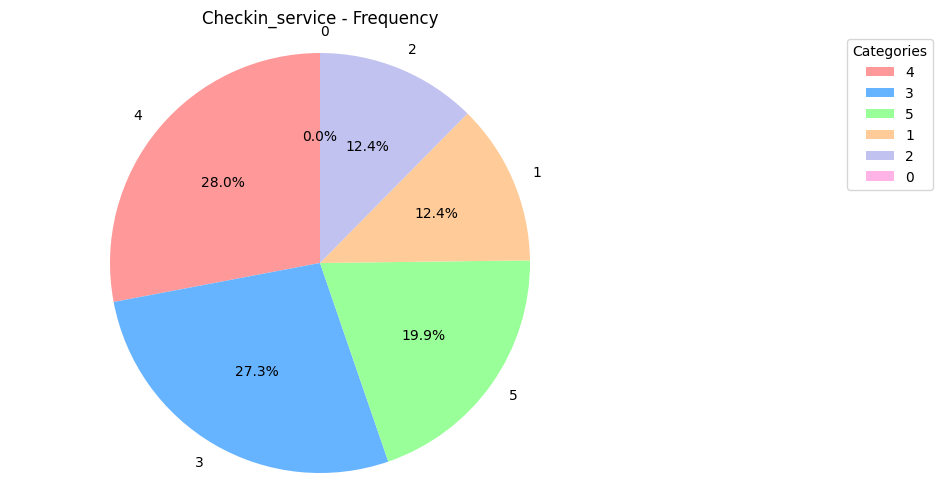

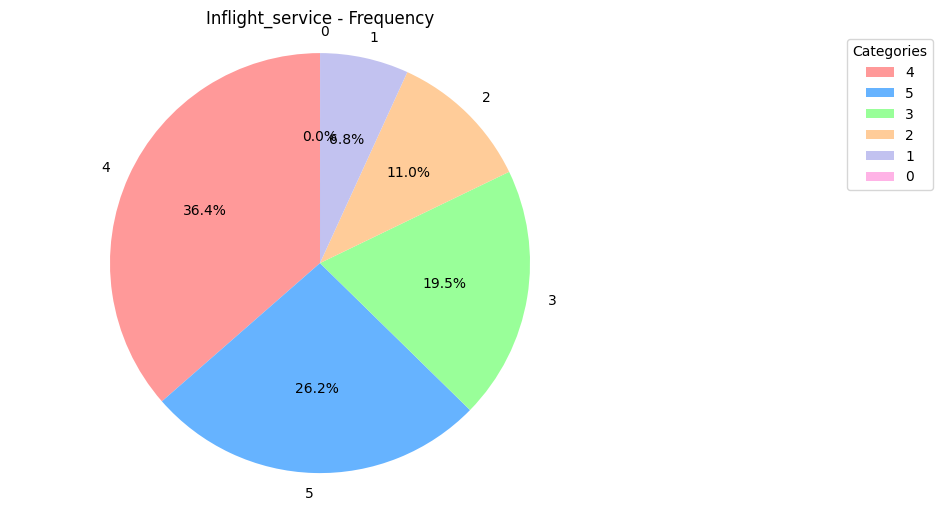

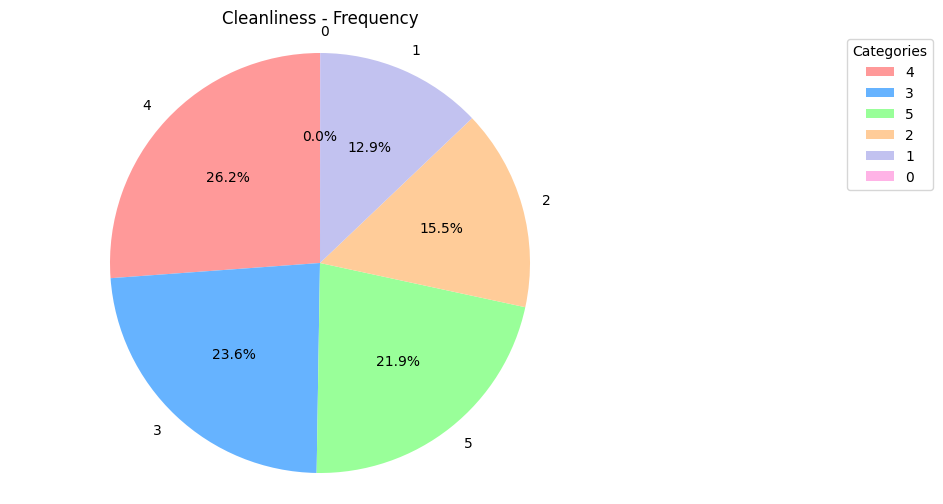

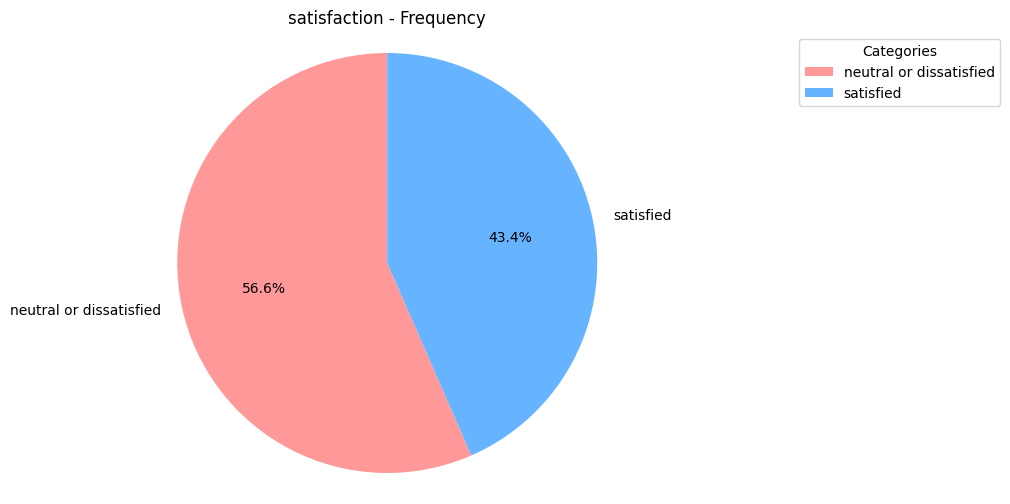

In [24]:
generate_pie_charts(Full_Set)

In [ ]:
Full_Set.columns

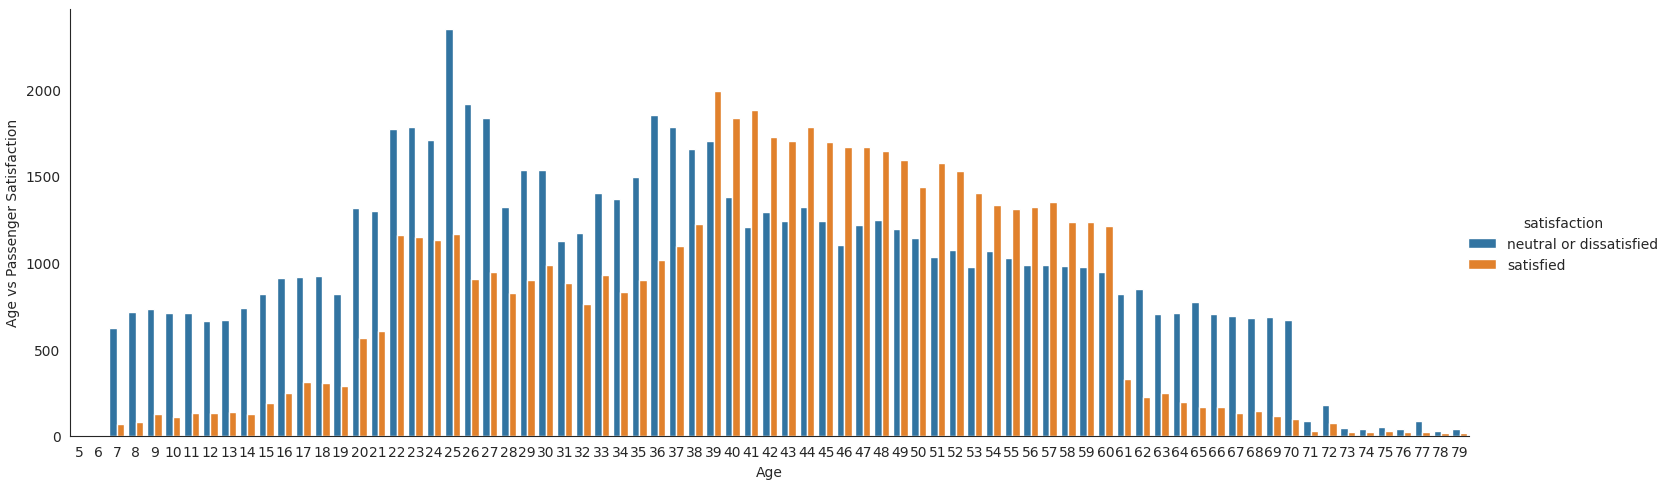

In [25]:
with sns.axes_style('white'):
    g = sns.catplot(x="Age", data=Full_Set, aspect=3.0, kind='count', hue='satisfaction', order=range(5, 80))
    g.set_ylabels('Age vs Passenger Satisfaction')


*Age:* From age 7-to-38 and from age 61-to-79, quotient of dissatisfied passengers is very high compared to satisfied passengers. On the contrary, in age range 39-60, quotient of satisfied passengers is higher compared to dissatisfied passengers.

# Bar Graph

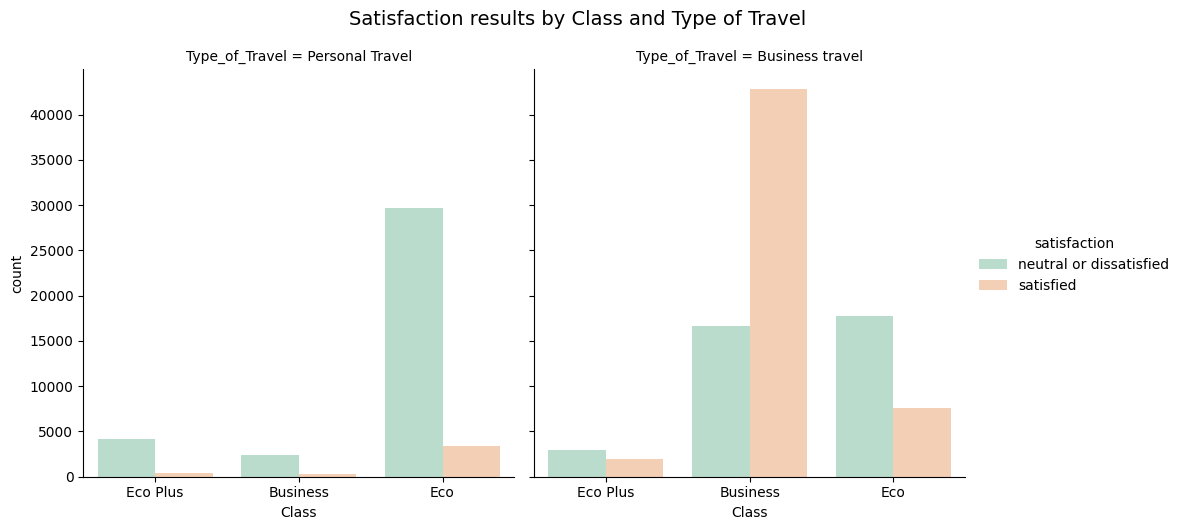

In [6]:
sns.catplot(x='Class', hue ="satisfaction", kind = "count", col = "Type_of_Travel", 
            data = Full_Set ,palette ="Pastel2", height = 5)
plt.suptitle("Satisfaction results by Class and Type of Travel", y = 1.05, fontsize= 14)
plt.show()

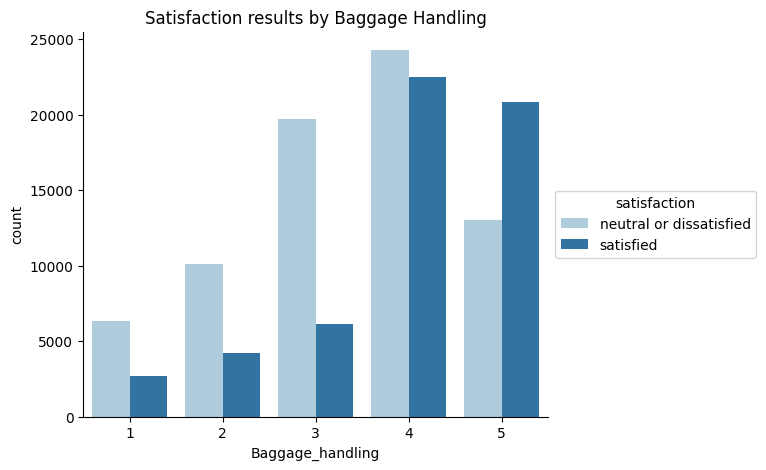

In [9]:
plt.figure(figsize = (6,5))
sns.countplot(x ="Baggage_handling", data = Full_Set, hue ="satisfaction",palette ="Paired" )
plt.title("Satisfaction results by Baggage Handling")
sns.despine(top = True, right = True, left = False, bottom = False)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),  title = "satisfaction")

plt.show()

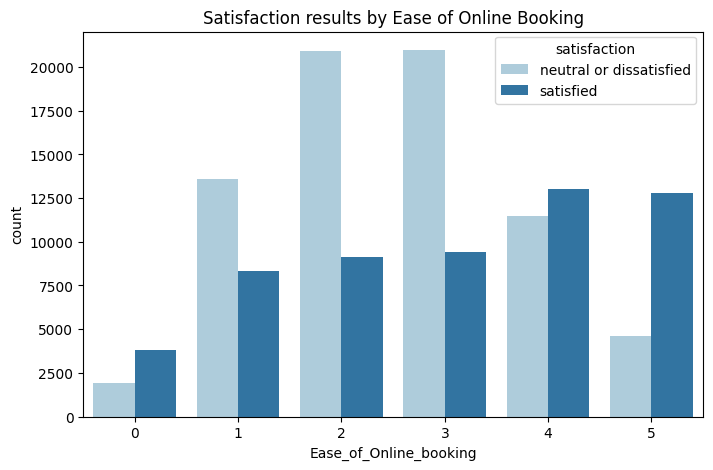

In [10]:
plt.figure(figsize = (8,5))
sns.countplot(x ="Ease_of_Online_booking", data = Full_Set, hue ="satisfaction",palette ="Paired" )

plt.title("Satisfaction results by Ease of Online Booking")
plt.legend(loc = 'center right', bbox_to_anchor=(1, 0.9),  title = "satisfaction")

plt.show()

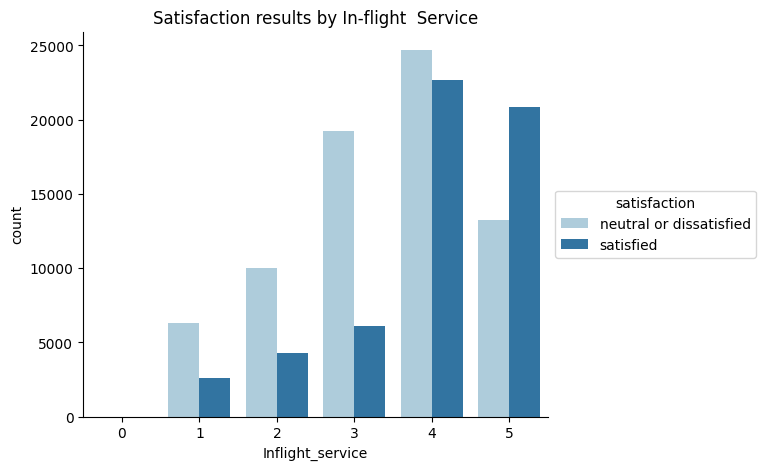

In [12]:
plt.figure(figsize = (6,5))
sns.countplot(x ="Inflight_service", data = Full_Set, hue ="satisfaction",palette ="Paired" )
plt.title("Satisfaction results by In-flight  Service")
sns.despine(top = True, right = True, left = False, bottom = False)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),  title = "satisfaction") 

plt.show()

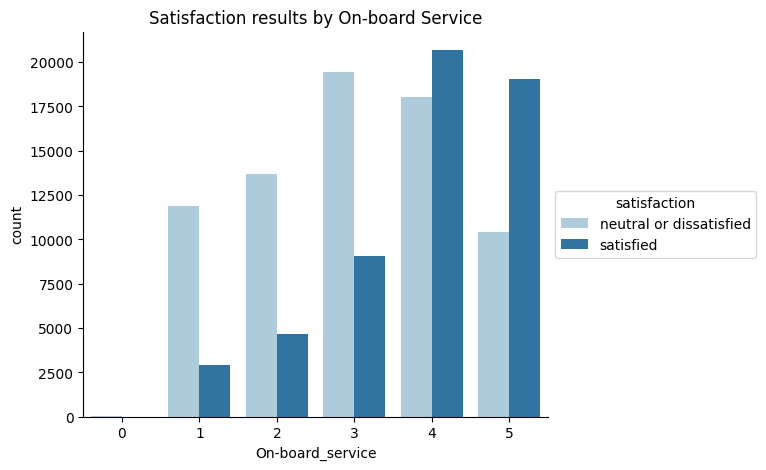

In [14]:
plt.figure(figsize = (6,5))
sns.countplot(x ="On-board_service", data = Full_Set, hue ="satisfaction",palette ="Paired" )
plt.title("Satisfaction results by On-board Service")
sns.despine(top = True, right = True, left = False, bottom = False)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),  title = "satisfaction") 

plt.show()

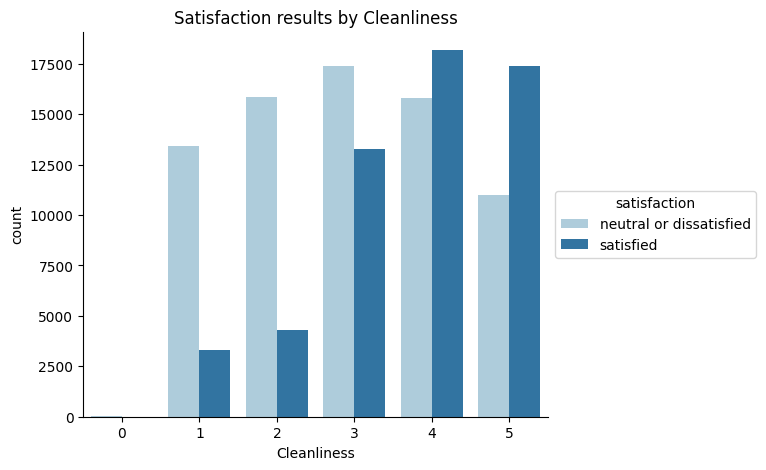

In [15]:
plt.figure(figsize = (6,5))
sns.countplot(x ="Cleanliness", data = Full_Set, hue ="satisfaction",palette ="Paired" )
plt.title("Satisfaction results by Cleanliness")
sns.despine(top = True, right = True, left = False, bottom = False)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title = "satisfaction") 

plt.show()

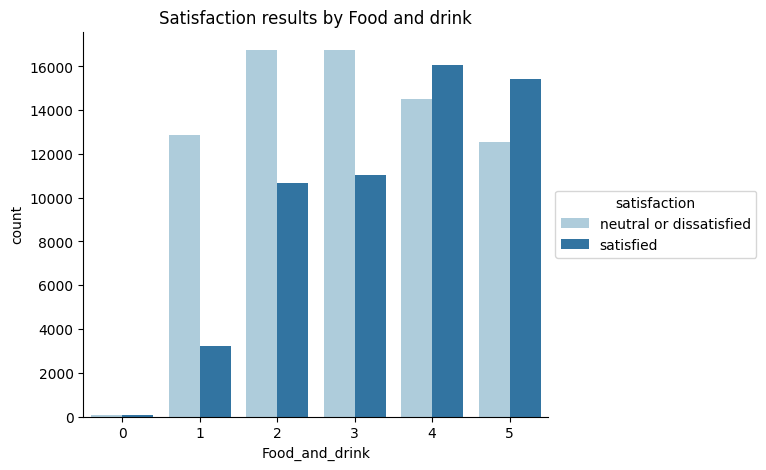

In [16]:
plt.figure(figsize = (6,5))
sns.countplot(x ="Food_and_drink", data = Full_Set, hue ="satisfaction", palette ="Paired" )
plt.title("Satisfaction results by Food and drink")
sns.despine(top = True, right = True, left = False, bottom = False)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title = "satisfaction") 

plt.show()

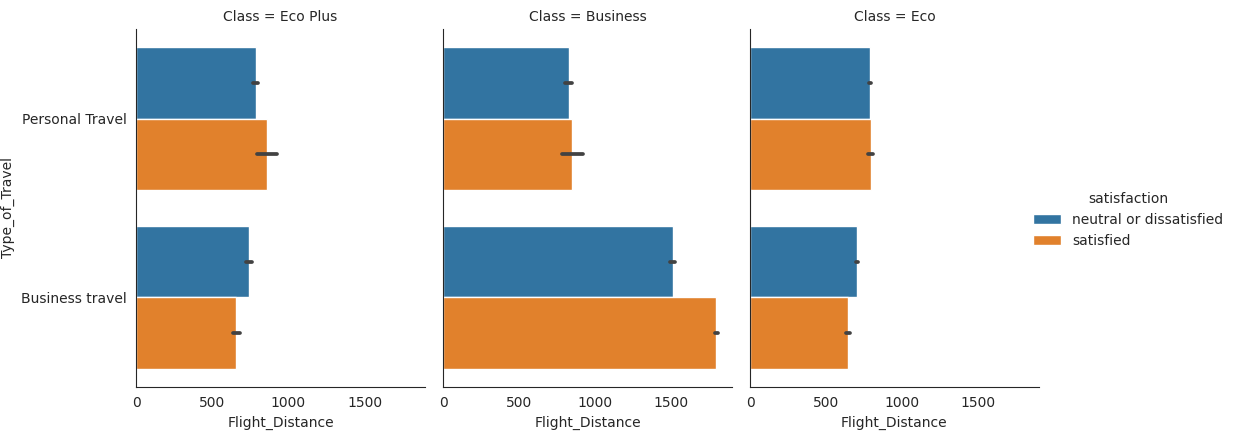

In [19]:
with sns.axes_style('white'):
    g = sns.catplot(x="Flight_Distance", y="Type_of_Travel", hue="satisfaction", col="Class", data=Full_Set, kind="bar", height=4.5, aspect=.8)

*Type of Travel, Class, Flight Distance*: For business travel in business class category, the number of satisfied passengers are quite on the higher side for longer flight distance. For other combinations, there is almost equal distribution of satisfied and dissatisfied passengers.

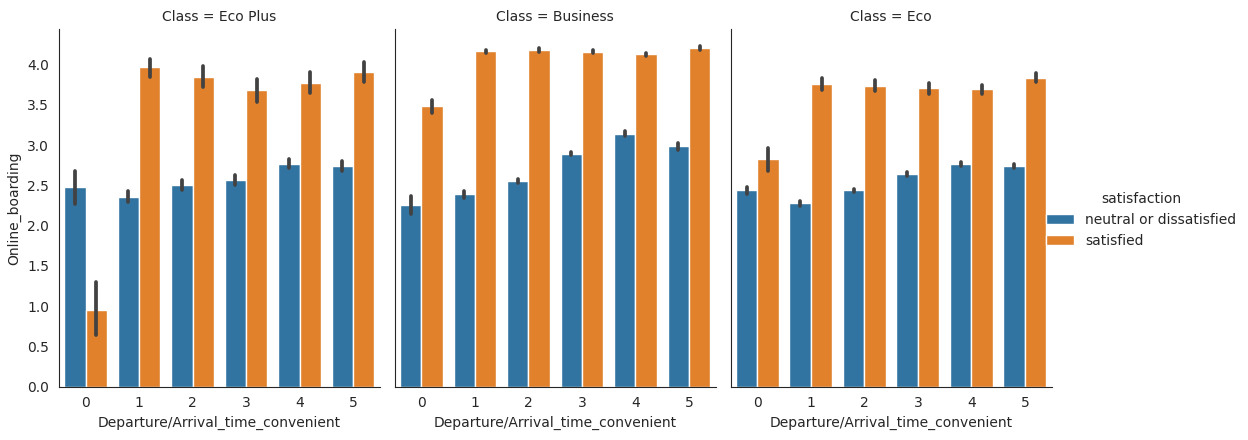

In [20]:
with sns.axes_style('white'):
    g = sns.catplot(x="Departure/Arrival_time_convenient", y="Online_boarding", hue="satisfaction", col="Class", data=Full_Set, kind="bar", height=4.5, aspect=.8)

*Online Boarding, Departure/Arrival Time Convenience grouped by Class:* For Eco Plus class, very inconvenient Departure/Arrival time (Departure/Arrival_time_convenient = 0) has really high no. of dissatisfied passengers, even when online boarding is done very well. For other combinations, no. of satisfied passengers are on the higher side compared to no. of dissatisfied passengers.